In [43]:
import pandas as pd
data = pd.read_csv("creditcard.csv")
print(data.head())
print(data.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [44]:
print(data['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [45]:
X = data.drop('Class',axis=1)
Y = data['Class']
print(X.head())
print(Y.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, Y_train)

RandomForestClassifier()

In [48]:
import joblib

joblib.dump(model, "fraud_model.pkl")

['fraud_model.pkl']

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [50]:
predictions = model.predict(X_test)

print(predictions[0:10])

[1 0 0 0 0 0 0 0 0 0]


In [51]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



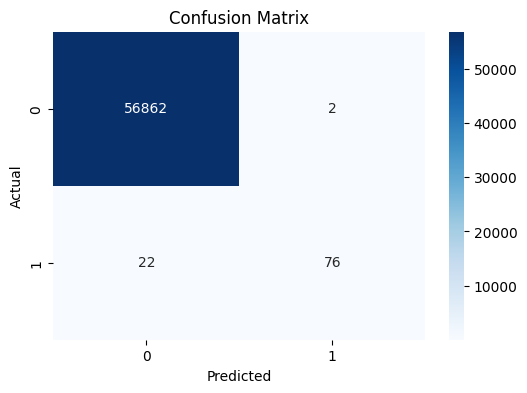

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(Y_test, predictions)

# Create graph area
plt.figure(figsize=(6,4))

# Draw heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add labels
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add title
plt.title("Confusion Matrix")

# Show graph
plt.show()

In [53]:
# Get importance scores from Random Forest model
importance = model.feature_importances_

# Get feature/column names
feature_names = X.columns

# Combine feature names with importance scores
feature_importance = pd.Series(
    importance,
    index=feature_names
).sort_values(ascending=False)

# Show top 10 important features
print(feature_importance.head(10))

V17    0.158351
V12    0.138534
V14    0.138214
V10    0.080572
V11    0.064650
V16    0.054721
V9     0.035681
V7     0.029431
V18    0.025747
V4     0.024574
dtype: float64


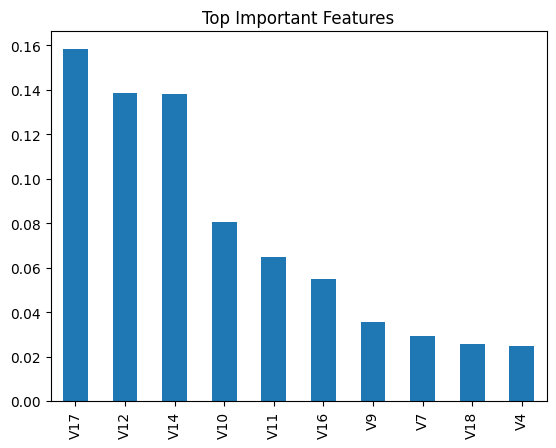

In [54]:
feature_importance.head(10).plot(kind='bar')

plt.title("Top Important Features")

plt.show()

In [55]:
import pandas as pd

complaints = {
    "text": [
        "My card was used without permission",
        "Unauthorized transaction from my account",
        "Loan amount not credited",
        "Home loan processing delayed",
        "ATM cash not dispensed",
        "Cash withdrawal failed at ATM",
        "Credit card payment issue",
        "Fraud transaction detected",
        "Personal loan application rejected",
        "ATM machine not working"
    ],

    "category": [
        "Fraud",
        "Fraud",
        "Loan",
        "Loan",
        "ATM",
        "ATM",
        "Card",
        "Fraud",
        "Loan",
        "ATM"
    ]
}

df = pd.DataFrame(complaints)

print(df)

                                       text category
0       My card was used without permission    Fraud
1  Unauthorized transaction from my account    Fraud
2                  Loan amount not credited     Loan
3              Home loan processing delayed     Loan
4                    ATM cash not dispensed      ATM
5             Cash withdrawal failed at ATM      ATM
6                 Credit card payment issue     Card
7                Fraud transaction detected    Fraud
8        Personal loan application rejected     Loan
9                   ATM machine not working      ATM


In [56]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["text"])

Y = df["category"]

print(X.toarray())

[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1]]


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.naive_bayes import MultinomialNB

nlp_model = MultinomialNB()

nlp_model.fit(X_train, Y_train)

MultinomialNB()

In [59]:
import joblib

joblib.dump(nlp_model, "nlp_model.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [61]:
sample = ["Unauthorized money transfer from my account"]

sample_vector = vectorizer.transform(sample)

prediction = nlp_model.predict(sample_vector)

print(prediction)

['Fraud']
